# Quickstart

[**User Guide**](https://millerbrainobservatory.github.io/LBM-Suite2p-Python/user_guide.html) | 
[**Supported Filetypes**](https://millerbrainobservatory.github.io/mbo_utilities/array_types.html#quick-reference) | 
[**API Reference**](https://millerbrainobservatory.github.io/LBM-Suite2p-Python/api.html) | 
[**MBO Hub**](https://millerbrainobservatory.github.io/)

Suite2p-based calcium imaging pipeline for Light Beads Microscopy data.

The only required parameter is the input data.

`input_data` can be any filepath or Lazy Array supported by [imread](https://millerbrainobservatory.github.io/mbo_utilities/user_guide.html#reading-and-writing-data).

In [1]:
import lbm_suite2p_python as lsp

# run the pipeline with all defaults
# lsp.pipeline("path/to/data")

In [ ]:
import lbm_suite2p_python as lsp

ops = {
    "diameter": 3,
    "anatomical_only": 3,
    "accept_all_cells": True,
    "spatial_hp_cp": 3,
    "denoise": 1,
    "two_step_registration": 1,
}

input_data = r"X:\lbm\kbarber\2025-11-04-mk311\raw"
save_path = r"X:\lbm\kbarber\2025-11-04-mk311\suite2p"

results = lsp.pipeline(
    input_data=input_data,      # path to .zarr, .tiff, or .bin file
    save_path=save_path,        # default: save next to input file
    ops=ops,                    # default: use MBO-optimized parameters
    planes=None,                   # process single plane (1-indexed)
    roi_mode=None,              # default: stitch multi-ROI data
    keep_reg=False,              # default: keep data.bin (registered binary)
    keep_raw=False,             # default: delete data_raw.bin after processing
    force_reg=False,            # default: skip if already registered
    force_detect=False,         # default: skip if stat.npy exists
    num_timepoints=None,        # default: use all frames
    dff_window_size=None,       # default: auto-calculate from tau and framerate
    dff_percentile=20,          # default: 20th percentile for baseline
    dff_smooth_window=None,     # default: auto-calculate from tau and framerate
    reader_kwargs={
        "fix_phase": True,      # default: MboRawArrays correct phase by default
        "use_fft": True,        # default: MboRawArrays use FFT default
    },
)

Loading input to determine dimensions: X:\lbm\kbarber\2025-11-04-mk311\raw


Counting frames:   0%|          | 0/379 [00:00<?, ?it/s]

Delegating to run_volume (4D input detected)...
Processing 14 planes in volume (Total planes: 14)
Output: X:\lbm\kbarber\2025-11-04-mk311\suite2p

--- Volume Step: Plane 1 ---
Importing suite2p packages...
Writing binary to X:\lbm\kbarber\2025-11-04-mk311\suite2p\mk311_11_04_2025_180mw_right_ppc_go_to_2x-mROI-896x896um_224x448px_2um-px_17p07Hz_green_00091...


Saving data_raw.bin:   0%|          | 0/226 [00:00<?, ?it/s]

Saving data_raw.bin:   0%|          | 0/226 [00:00<?, ?it/s]

...

Saving data_raw.bin:   0%|          | 0/226 [00:00<?, ?it/s]

Saving data_raw.bin:   0%|          | 0/226 [00:00<?, ?it/s]

Saving data_raw.bin:   0%|          | 0/226 [00:00<?, ?it/s]

Saving data_raw.bin:   0%|          | 0/226 [00:00<?, ?it/s]

Saving data_raw.bin:   0%|          | 0/226 [00:00<?, ?it/s]

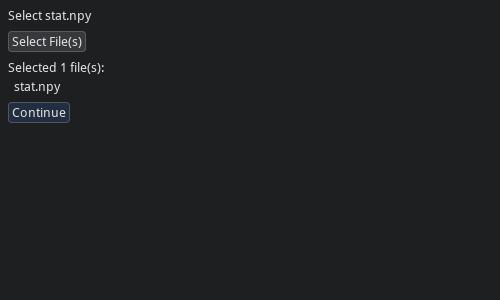

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from mbo_utilities import select_files, load_ops
import lbm_suite2p_python as lsp

# select stat.npy file
files = select_files(
    title="Select stat.npy",
    filters=["Stat files", "*.npy"],
)
if not files:
    raise ValueError("No file selected")

stat_path = files[0]
plane_dir = stat_path.parent

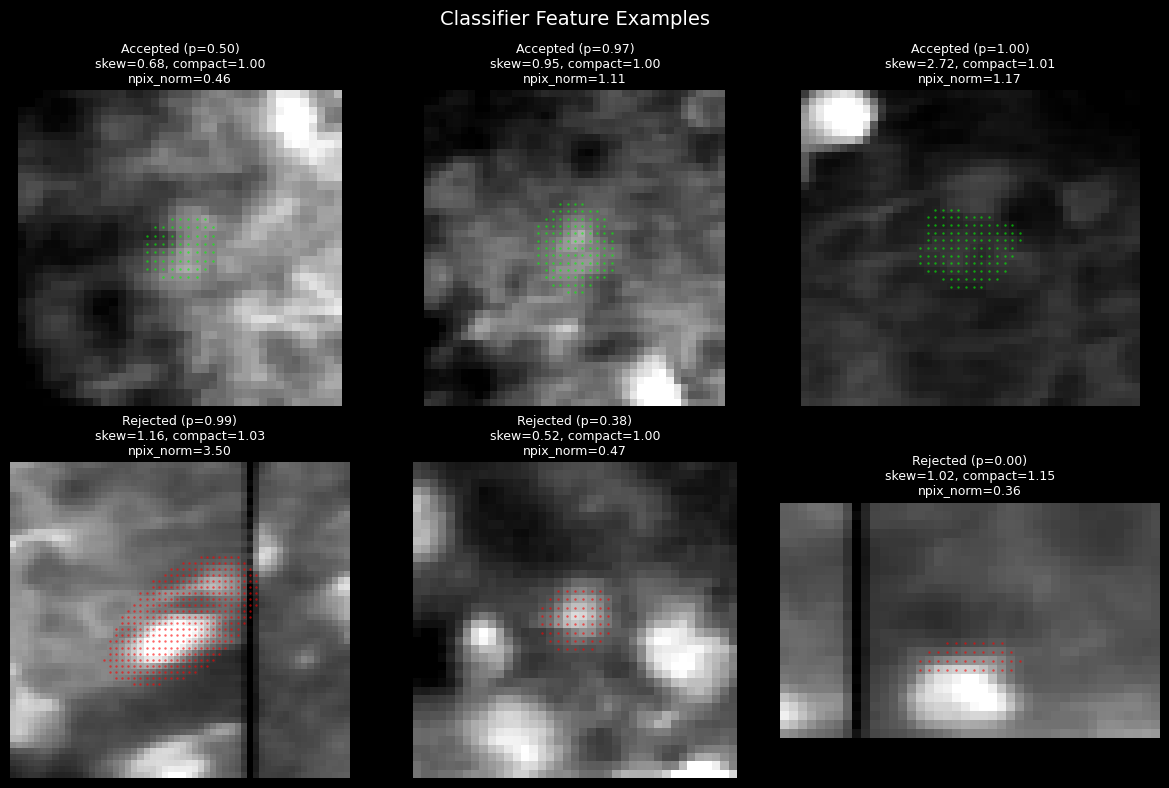

In [5]:
# load data
stat = np.load(stat_path, allow_pickle=True)
ops = load_ops(plane_dir / "ops.npy")

iscell = np.load(plane_dir / "iscell.npy")

mean_img = ops.get("meanImg", ops.get("meanImgE"))
Ly, Lx = mean_img.shape

# get 3 accepted and 3 rejected cells sorted by classifier probability
probs = iscell[:, 1]
accepted_idx = np.where(iscell[:, 0] == 1)[0]
rejected_idx = np.where(iscell[:, 0] == 0)[0]

# pick 3 from each, spread across probability range
n_examples = 3
acc_sorted = accepted_idx[np.argsort(probs[accepted_idx])]
rej_sorted = rejected_idx[np.argsort(probs[rejected_idx])[::-1]]
examples_acc = acc_sorted[np.linspace(0, len(acc_sorted)-1, n_examples, dtype=int)]
examples_rej = rej_sorted[np.linspace(0, len(rej_sorted)-1, n_examples, dtype=int)]

# plot
fig, axes = plt.subplots(2, n_examples, figsize=(12, 8))
fig.suptitle("Classifier Feature Examples", fontsize=14)

for col, (label, indices, color) in enumerate([
    ("Accepted", examples_acc, "lime"),
    ("Rejected", examples_rej, "red"),
]):
    for row, idx in enumerate(indices):
        ax = axes[col, row] if n_examples > 1 else axes[col]
        s = stat[idx]

        # extract roi region with padding
        ypix, xpix = s["ypix"], s["xpix"]
        pad = 15
        y0, y1 = max(0, ypix.min() - pad), min(Ly, ypix.max() + pad + 1)
        x0, x1 = max(0, xpix.min() - pad), min(Lx, xpix.max() + pad + 1)

        roi_img = mean_img[y0:y1, x0:x1]
        ax.imshow(roi_img, cmap="gray", vmin=np.percentile(roi_img, 1),
                  vmax=np.percentile(roi_img, 99))

        # overlay mask
        local_y, local_x = ypix - y0, xpix - x0
        ax.scatter(local_x, local_y, c=color, s=3, alpha=0.6, linewidths=0)

        # show features
        prob = probs[idx]
        skew = s.get("skew", np.nan)
        compact = s.get("compact", np.nan)
        npix_norm = s.get("npix_norm", np.nan)

        title = f"{label} (p={prob:.2f})\nskew={skew:.2f}, compact={compact:.2f}\nnpix_norm={npix_norm:.2f}"
        ax.set_title(title, fontsize=9)
        ax.axis("off")

plt.tight_layout()
plt.show()

## Load Results

In [ ]:
results = lsp.load_planar_results(ops_files[0])

F = results["F"]           # (n_rois, n_frames)
Fneu = results["Fneu"]     # (n_rois, n_frames)
stat = results["stat"]     # ROI stats
iscell = results["iscell"] # (n_rois, 2)

print(f"ROIs: {len(stat)}, Accepted: {iscell[:, 0].sum():.0f}")

## Compute ΔF/F

In [ ]:
iscell_mask = iscell[:, 0].astype(bool)
F_cells = F[iscell_mask]

dff = lsp.dff_rolling_percentile(
    F_cells,
    window_size=300,  # 10 × tau × framerate
    percentile=20,
)

## Suite2p GUI

In [ ]:
from suite2p import gui
gui.run(statfile=str(ops_files[0].parent / "stat.npy"))

In [2]:
import lbm_suite2p_python as lsp
import matplotlib.pyplot as plt

# basic usage
fig = lsp.plot_3d_rastermap_clusters("D:/demo/results/suite2p")
plt.show()

# with custom clusters
# fig = lsp.plot_3d_rastermap_clusters("D:/demo/results/suite2p", n_clusters=50)

# save to file
# fig = lsp.plot_3d_rastermap_clusters("D:/demo/results/suite2p", save_path="rastermap_clusters.png")


<Figure size 1400x1000 with 0 Axes>

---

## What's Next

- [User Guide](https://millerbrainobservatory.github.io/LBM-Suite2p-Python/user_guide.html) - Parameters, outputs, troubleshooting
- [Grid Search](https://github.com/MillerBrainObservatory/LBM-Suite2p-Python/blob/master/dev/grid_search.ipynb) - Optimize parameters
- [Postprocessing](https://millerbrainobservatory.github.io/LBM-Suite2p-Python/postprocessing.html) - Filters and quality metrics